# Multi-Objective Movie Recommendation with Matrix Factorization and Whale Optimization

This notebook implements a movie recommendation system using the **MovieLens 100K** dataset.

The recommendation pipeline combines a **Matrix Factorization (MF)** model with a **Multi-Objective Whale Optimization Algorithm (MOWOA)** to balance recommendation accuracy and diversity.

The main objectives of this project are:

- Prepare and preprocess the MovieLens 100K dataset
- Perform a per-user time-aware train/validation/test split
- Train a Matrix Factorization model using NumPy and SGD
- Generate candidate movies using predicted MF scores
- Build a Top-K Matrix Factorization baseline
- Re-rank candidate movies using multi-objective Whale Optimization
- Optimize both predicted relevance and intra-list diversity
- Enforce a minimum genre-diversity constraint
- Compare MF and MOWOA using accuracy, diversity, coverage, and exposure metrics
- Visualize the trade-off between recommendation quality and diversity

## 1. Environment Setup and Dataset Acquisition

This section initializes the required Python libraries, downloads the MovieLens dataset, and defines the random state used throughout the notebook.

The main libraries used in this project include:

- NumPy
- Pandas
- Matplotlib
- gdown

The MovieLens dataset is downloaded as a compressed archive and extracted into the working directory.

A fixed random state is also defined to improve reproducibility across data-processing steps.

In [ ]:
import os
import time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

try:
    from IPython.display import display
except:
    display = print

import gdown

file_id = "1EDXNRxjkjZ0CP3v_mZJ47zyUxIrjOvpM"
# url = 'https://drive.google.com/file/d/1EDXNRxjkjZ0CP3v_mZJ47zyUxIrjOvpM/'
output = "movielens.zip"
gdown.download(id=file_id, output=output)

!unzip movielens.zip
!rm movielens.zip

RANDOM_STATE = 42
rng = np.random.default_rng(RANDOM_STATE)


Downloading...
From: https://drive.google.com/uc?id=1oeKcu8pLOQsU6EpvoEVMGTJJywII1IIw
To: /kaggle/working/movielens.zip
100%|██████████| 892k/892k [00:00<00:00, 123MB/s]

Archive:  movielens.zip
   creating: Movielens/
  inflating: Movielens/u.genre       
  inflating: Movielens/u.user        
  inflating: Movielens/u.item        
  inflating: Movielens/u.data        


## 2. Loading the MovieLens 100K Dataset

The MovieLens dataset is loaded from the extracted data directory.

The following files are used:

- `u.data` — user-item ratings and timestamps
- `u.user` — user demographic information
- `u.item` — movie metadata and genre indicators
- `u.genre` — genre names and identifiers

The movie metadata contains 19 binary genre indicators for each movie.

The loaded tables are inspected before further preprocessing.

In [ ]:
DATA_DIR = "./Movielens"
os.listdir(DATA_DIR)

ratings = pd.read_csv(
    f"{DATA_DIR}/u.data",
    sep="\t",
    names=["user_id", "item_id", "rating", "timestamp"]
)

users = pd.read_csv(
    f"{DATA_DIR}/u.user",
    sep="|",
    names=["user_id", "age", "gender", "occupation", "zip_code"]
)

items_raw = pd.read_csv(
    f"{DATA_DIR}/u.item",
    sep="|",
    encoding="latin-1",
    header=None
)

# u.item: first 5 fields + 19 genre flags
item_cols = ["movie_id", "title", "release_date", "video_release_date", "imdb_url"] + [f"g{i}" for i in range(19)]
items_raw.columns = item_cols

genres = pd.read_csv(
    f"{DATA_DIR}/u.genre",
    sep="|",
    names=["genre", "genre_id"]
)

# Clean u.genre (drop possible empty last line)
genres_clean = genres.dropna(subset=["genre", "genre_id"]).copy()
genres_clean["genre_id"] = genres_clean["genre_id"].astype(int)
genres_clean = genres_clean.sort_values("genre_id").reset_index(drop=True)

display(ratings.head())
display(users.head())
display(items_raw.head())
display(genres_clean)


,user_id,item_id,rating,timestamp
0,196,242,3,881250949
1,186,302,3,891717742
2,22,377,1,878887116
3,244,51,2,880606923
4,166,346,1,886397596


,user_id,age,gender,occupation,zip_code
0,1,24,M,technician,85711
1,2,53,F,other,94043
2,3,23,M,writer,32067
3,4,24,M,technician,43537
4,5,33,F,other,15213


,movie_id,title,release_date,video_release_date,imdb_url,g0,g1,g2,g3,g4,...,g9,g10,g11,g12,g13,g14,g15,g16,g17,g18
0,1,Toy Story (1995),01-Jan-1995,NaN,http://us.imdb.com/M/title-exact?Toy%20Story%2...,0,0,0,1,1,...,0,0,0,0,0,0,0,0,0,0
1,2,GoldenEye (1995),01-Jan-1995,NaN,http://us.imdb.com/M/title-exact?GoldenEye%20(...,0,1,1,0,0,...,0,0,0,0,0,0,0,1,0,0
2,3,Four Rooms (1995),01-Jan-1995,NaN,http://us.imdb.com/M/title-exact?Four%20Rooms%...,0,0,0,0,0,...,0,0,0,0,0,0,0,1,0,0
3,4,Get Shorty (1995),01-Jan-1995,NaN,http://us.imdb.com/M/title-exact?Get%20Shorty%...,0,1,0,0,0,...,0,0,0,0,0,0,0,0,0,0
4,5,Copycat (1995),01-Jan-1995,NaN,http://us.imdb.com/M/title-exact?Copycat%20(1995),0,0,0,0,0,...,0,0,0,0,0,0,0,1,0,0


,genre,genre_id
0,unknown,0
1,Action,1
2,Adventure,2
3,Animation,3
4,Children's,4
5,Comedy,5
6,Crime,6
7,Documentary,7
8,Drama,8
9,Fantasy,9


## 3. Movie-Genre Mapping and Rating Preprocessing

Movie genre indicators are converted into a list of genre IDs associated with each movie.

The resulting genre information is merged with the rating data to produce two representations:

- `ratings_with_genres` — one row per user-item interaction with a list of genres
- `ratings_exploded` — one row per user-item-genre combination

These representations are used later for recommendation evaluation and genre-diversity analysis.

The processed datasets are also saved for reuse.

In [ ]:
# Build: item_id -> list of genre_ids
def get_genre_ids_from_row(row):
    return [i for i in range(19) if int(row[f"g{i}"]) == 1]

movie_genres_df = items_raw[["movie_id"] + [f"g{i}" for i in range(19)]].copy()
movie_genres_df["genre_ids"] = movie_genres_df.apply(get_genre_ids_from_row, axis=1)
movie_genres_df = movie_genres_df.rename(columns={"movie_id": "item_id"})[["item_id", "genre_ids"]]

ratings_with_genres = ratings.merge(movie_genres_df, on="item_id", how="left")
ratings_exploded = ratings_with_genres.explode("genre_ids").rename(columns={"genre_ids": "genre_id"})

print("ratings_with_genres:", ratings_with_genres.shape)
print("ratings_exploded   :", ratings_exploded.shape)
display(ratings_with_genres.head())
display(ratings_exploded.head())

# Save processed
PROCESSED_DIR = "./movielens_data/processed"
os.makedirs(PROCESSED_DIR, exist_ok=True)

ratings_with_genres.to_csv(os.path.join(PROCESSED_DIR, "ratings_with_genres.csv"), index=False)
ratings_exploded.to_csv(os.path.join(PROCESSED_DIR, "ratings_exploded.csv"), index=False)

print("✅ Saved processed to:", PROCESSED_DIR)


ratings_with_genres: (100000, 5)
ratings_exploded   : (212595, 5)


,user_id,item_id,rating,timestamp,genre_ids
0,196,242,3,881250949,[5]
1,186,302,3,891717742,"[6, 10, 13, 16]"
2,22,377,1,878887116,"[4, 5]"
3,244,51,2,880606923,"[8, 14, 17, 18]"
4,166,346,1,886397596,"[6, 8]"


,user_id,item_id,rating,timestamp,genre_id
0,196,242,3,881250949,5
1,186,302,3,891717742,6
1,186,302,3,891717742,10
1,186,302,3,891717742,13
1,186,302,3,891717742,16


✅ Saved processed to: /content/drive/MyDrive/A - EA Exercise/movielens/processed


## 4. Per-User Time-Aware Data Splitting

The interaction history of each user is divided into training, validation, and test sets using a **time-aware splitting strategy**.

For each user, interactions are sorted chronologically so that older interactions are used for training while more recent interactions are reserved for validation and testing.

The split configuration includes:

- Test fraction: 10%
- Validation fraction: 20%
- Minimum number of test interactions per eligible user: 10
- Minimum number of validation interactions per eligible user: 5

This strategy provides a more realistic recommendation setting because the model is trained on past interactions and evaluated on future user behavior.

The exploded genre-level dataset is filtered using the same interaction keys to ensure consistency between all dataset representations.

In [ ]:
SPLITS_DIR = "./movielens_data/splits_mf"
os.makedirs(SPLITS_DIR, exist_ok=True)

TEST_FRAC = 0.10
VAL_FRAC  = 0.20

MIN_RATINGS_PER_USER = 5
MIN_TEST_PER_USER = 10
MIN_VAL_PER_USER  = 5

def per_user_split(df, user_col="user_id", time_col="timestamp",
                   test_frac=0.10, val_frac=0.20, random_state=42,
                   min_ratings_per_user=5, min_test_per_user=1, min_val_per_user=1,
                   time_aware=True):
    rng_local = np.random.default_rng(random_state)
    train_parts, val_parts, test_parts = [], [], []

    for uid, g in df.groupby(user_col, sort=False):
        g = g.copy()
        n = len(g)

        if n < min_ratings_per_user:
            train_parts.append(g)
            continue

        n_test = max(min_test_per_user, int(round(n * test_frac)))
        n_val  = max(min_val_per_user,  int(round(n * val_frac)))

        if n_test + n_val >= n:
            n_test = min(n_test, n - 1)
            n_val  = min(n_val,  n - 1 - n_test)

        if time_aware and time_col in g.columns:
            g = g.sort_values(time_col)
            test = g.iloc[-n_test:] if n_test > 0 else g.iloc[0:0]
            remain = g.iloc[: n - n_test]
            val = remain.iloc[-n_val:] if n_val > 0 else remain.iloc[0:0]
            train = remain.iloc[: len(remain) - len(val)]
        else:
            idx = np.arange(n)
            rng_local.shuffle(idx)
            test_idx = idx[:n_test]
            val_idx  = idx[n_test:n_test+n_val]
            train_idx = idx[n_test+n_val:]
            test = g.iloc[test_idx]
            val  = g.iloc[val_idx]
            train = g.iloc[train_idx]

        train_parts.append(train)
        val_parts.append(val)
        test_parts.append(test)

    return (
        pd.concat(train_parts, ignore_index=True),
        pd.concat(val_parts,   ignore_index=True),
        pd.concat(test_parts,  ignore_index=True),
    )

rw_train, rw_val, rw_test = per_user_split(
    ratings_with_genres,
    test_frac=TEST_FRAC,
    val_frac=VAL_FRAC,
    random_state=RANDOM_STATE,
    min_ratings_per_user=MIN_RATINGS_PER_USER,
    min_test_per_user=MIN_TEST_PER_USER,
    min_val_per_user=MIN_VAL_PER_USER,
    time_aware=True
)

# Make exploded splits consistent with base splits
key_cols = ["user_id", "item_id", "timestamp"]

def filter_exploded(exploded_df, base_split_df):
    keys = base_split_df[key_cols].drop_duplicates()
    return exploded_df.merge(keys, on=key_cols, how="inner")

re_train = filter_exploded(ratings_exploded, rw_train)
re_val   = filter_exploded(ratings_exploded, rw_val)
re_test  = filter_exploded(ratings_exploded, rw_test)

# Save
rw_train.to_csv(os.path.join(SPLITS_DIR, "ratings_with_genres_train.csv"), index=False)
rw_val.to_csv(os.path.join(SPLITS_DIR, "ratings_with_genres_val.csv"), index=False)
rw_test.to_csv(os.path.join(SPLITS_DIR, "ratings_with_genres_test.csv"), index=False)

re_train.to_csv(os.path.join(SPLITS_DIR, "ratings_exploded_train.csv"), index=False)
re_val.to_csv(os.path.join(SPLITS_DIR, "ratings_exploded_val.csv"), index=False)
re_test.to_csv(os.path.join(SPLITS_DIR, "ratings_exploded_test.csv"), index=False)

print("✅ Saved splits to:", SPLITS_DIR)
print("train/val/test:", rw_train.shape, rw_val.shape, rw_test.shape)

train_users = set(rw_train["user_id"].unique())
test_users  = set(rw_test["user_id"].unique())
print("Cold-start users in test (should be 0):", len(test_users - train_users))


✅ Saved splits to: ./movielens_data/splits_mf
train/val/test: (66680, 5) (20079, 5) (13241, 5)
Cold-start users in test (should be 0): 0


## 5. Matrix Factorization Baseline

A Matrix Factorization (MF) recommender is implemented from scratch using NumPy and stochastic gradient descent.

The predicted rating is modeled using:

- Global mean rating
- User bias
- Item bias
- User latent factors
- Item latent factors

The current configuration uses:

- 128 latent factors
- 50 training epochs
- Learning rate of 0.01
- L2 regularization coefficient of 0.02

Only users and items observed in the training data are included during validation and test evaluation.

Model performance is measured using:

- Root Mean Squared Error (RMSE)
- Mean Absolute Error (MAE)

In [ ]:
from math import sqrt

# MF hyperparams
n_factors = 128
n_epochs  = 50
lr        = 0.01
reg       = 0.02
seed      = 42

def rmse_mae(y_true, y_pred):
    y_true = np.asarray(y_true, dtype=np.float32)
    y_pred = np.asarray(y_pred, dtype=np.float32)
    mse = np.mean((y_true - y_pred) ** 2)
    mae = np.mean(np.abs(y_true - y_pred))
    return float(np.sqrt(mse)), float(mae)

train = rw_train[["user_id","item_id","rating"]].copy()
val   = rw_val[["user_id","item_id","rating"]].copy()
test  = rw_test[["user_id","item_id","rating"]].copy()

# Build mappings from TRAIN
user_ids = train["user_id"].unique()
item_ids = train["item_id"].unique()
user2idx = {u:i for i,u in enumerate(user_ids)}
item2idx = {m:i for i,m in enumerate(item_ids)}

n_users = len(user2idx)
n_items = len(item2idx)

# Filter val/test to only ids seen in train
val_f = val[val["user_id"].isin(user2idx) & val["item_id"].isin(item2idx)].copy()
test_f = test[test["user_id"].isin(user2idx) & test["item_id"].isin(item2idx)].copy()

def to_idx(df):
    u = df["user_id"].map(user2idx).to_numpy(dtype=np.int32)
    i = df["item_id"].map(item2idx).to_numpy(dtype=np.int32)
    r = df["rating"].to_numpy(dtype=np.float32)
    return u, i, r

u_train, i_train, r_train = to_idx(train)
u_val, i_val, r_val       = to_idx(val_f)  if len(val_f)  else (np.array([],np.int32), np.array([],np.int32), np.array([],np.float32))
u_test, i_test, r_test    = to_idx(test_f) if len(test_f) else (np.array([],np.int32), np.array([],np.int32), np.array([],np.float32))

rng_mf = np.random.default_rng(seed)
P = 0.1 * rng_mf.standard_normal((n_users, n_factors)).astype(np.float32)
Q = 0.1 * rng_mf.standard_normal((n_items, n_factors)).astype(np.float32)
bu = np.zeros(n_users, dtype=np.float32)
bi = np.zeros(n_items, dtype=np.float32)
mu = np.mean(r_train).astype(np.float32)

def predict_idx(u_idx, i_idx):
    return mu + bu[u_idx] + bi[i_idx] + np.sum(P[u_idx] * Q[i_idx], axis=1)

print(f"Training MF: users={n_users}, items={n_items}, factors={n_factors}")
for epoch in range(1, n_epochs + 1):
    perm = rng_mf.permutation(len(r_train))
    u_sh, i_sh, r_sh = u_train[perm], i_train[perm], r_train[perm]

    for u, it, r in zip(u_sh, i_sh, r_sh):
        pred = mu + bu[u] + bi[it] + np.dot(P[u], Q[it])
        err = r - pred

        pu = P[u].copy()
        qi = Q[it].copy()

        bu[u] += lr * (err - reg * bu[u])
        bi[it] += lr * (err - reg * bi[it])
        P[u]  += lr * (err * qi - reg * pu)
        Q[it] += lr * (err * pu - reg * qi)

    tr_pred = predict_idx(u_train, i_train)
    tr_rmse, tr_mae = rmse_mae(r_train, tr_pred)

    if len(r_val):
        va_pred = predict_idx(u_val, i_val)
        va_rmse, va_mae = rmse_mae(r_val, va_pred)
        print(f"Epoch {epoch:02d}: Train RMSE={tr_rmse:.4f} MAE={tr_mae:.4f} | Val RMSE={va_rmse:.4f} MAE={va_mae:.4f}")
    else:
        print(f"Epoch {epoch:02d}: Train RMSE={tr_rmse:.4f} MAE={tr_mae:.4f} | Val: (no overlap)")

if len(r_test):
    te_pred = predict_idx(u_test, i_test)
    te_rmse, te_mae = rmse_mae(r_test, te_pred)
    print(f"\nFinal TEST: RMSE={te_rmse:.4f} MAE={te_mae:.4f}  (on {len(r_test)} interactions)")
else:
    print("\nFinal TEST: (no overlap)")


Training MF: users=943, items=1573, factors=128
Epoch 01: Train RMSE=0.9359 MAE=0.7454 | Val RMSE=1.0463 MAE=0.8348
Epoch 02: Train RMSE=0.8946 MAE=0.7092 | Val RMSE=1.0204 MAE=0.8099
Epoch 03: Train RMSE=0.8654 MAE=0.6854 | Val RMSE=1.0090 MAE=0.7994
Epoch 04: Train RMSE=0.8388 MAE=0.6643 | Val RMSE=1.0015 MAE=0.7930
Epoch 05: Train RMSE=0.8117 MAE=0.6427 | Val RMSE=0.9962 MAE=0.7880
Epoch 06: Train RMSE=0.7824 MAE=0.6195 | Val RMSE=0.9927 MAE=0.7848
Epoch 07: Train RMSE=0.7505 MAE=0.5944 | Val RMSE=0.9880 MAE=0.7811
Epoch 08: Train RMSE=0.7165 MAE=0.5681 | Val RMSE=0.9858 MAE=0.7791
Epoch 09: Train RMSE=0.6814 MAE=0.5406 | Val RMSE=0.9833 MAE=0.7769
Epoch 10: Train RMSE=0.6462 MAE=0.5129 | Val RMSE=0.9820 MAE=0.7758
Epoch 11: Train RMSE=0.6116 MAE=0.4857 | Val RMSE=0.9803 MAE=0.7742
Epoch 12: Train RMSE=0.5781 MAE=0.4591 | Val RMSE=0.9808 MAE=0.7743
Epoch 13: Train RMSE=0.5464 MAE=0.4343 | Val RMSE=0.9807 MAE=0.7742
Epoch 14: Train RMSE=0.5167 MAE=0.4109 | Val RMSE=0.9811 MAE=0.7745


## 6. Candidate Generation and MF Top-K Recommendations

The trained Matrix Factorization model is used to create a candidate set for each user.

Movies already observed by the user in the training or validation sets are excluded from recommendation.

For each evaluation user:

1. All unseen training-catalog items are scored using the MF model.
2. The highest-scoring 300 movies are retained as candidate items.
3. The top 10 candidates form the Matrix Factorization baseline recommendation list.

An item is considered relevant during evaluation when its test rating is at least `4.0`.

The generated MF recommendation lists are saved for later comparison with the multi-objective optimization approach.

In [ ]:
N_CANDIDATES = 300
RELEVANT_THRESHOLD = 4.0
K=10
RESULTS_DIR = "./results_mf"
os.makedirs(RESULTS_DIR, exist_ok=True)

# seen items per user from train+val
seen = (
    pd.concat([rw_train[["user_id","item_id"]], rw_val[["user_id","item_id"]]], ignore_index=True)
    .groupby("user_id")["item_id"].apply(set).to_dict()
)

test_relevant = (
    test_f[test_f["rating"] >= RELEVANT_THRESHOLD]
    .groupby("user_id")["item_id"].apply(set).to_dict()
)

all_train_items = set(item2idx.keys())

def mf_top_n_candidates(user_id, n=N_CANDIDATES):
    if user_id not in user2idx:
        return [], np.array([], dtype=np.float32)
    uidx = user2idx[user_id]

    seen_items = seen.get(user_id, set())
    candidates = list(all_train_items - seen_items)
    if not candidates:
        return [], np.array([], dtype=np.float32)

    cand_iidx = np.array([item2idx[iid] for iid in candidates], dtype=np.int32)
    u_arr = np.full_like(cand_iidx, fill_value=uidx)
    scores = predict_idx(u_arr, cand_iidx).astype(np.float32)

    nn = min(n, len(scores))
    topn_pos = np.argpartition(-scores, kth=nn-1)[:nn]
    topn_sorted = topn_pos[np.argsort(-scores[topn_pos])]

    cands_topN = [candidates[j] for j in topn_sorted]
    scs_topN = scores[topn_sorted]
    return cands_topN, scs_topN

# Users evaluated = users who have >=1 relevant item in test
users_eval = sorted(test_relevant.keys())

# MF baseline (fair): Top-K from Top-N candidates
mf_rows = []
for uid in users_eval:
    cands, scs = mf_top_n_candidates(uid, N_CANDIDATES)
    if len(cands) < K:
        continue
    recs = cands[:K]
    rec_scores = scs[:K]
    for rank, (iid, sc) in enumerate(zip(recs, rec_scores), start=1):
        mf_rows.append({"user_id": int(uid), "item_id": int(iid), "rank": int(rank), "pred_rating": float(sc)})

mf_recs_df = pd.DataFrame(mf_rows).sort_values(["user_id","rank"])
mf_path = os.path.join(RESULTS_DIR, f"mf_top{K}_from_top{N_CANDIDATES}_candidates.csv")
mf_recs_df.to_csv(mf_path, index=False)
print("✅ Saved MF baseline recs:", mf_path)
display(mf_recs_df.head())


✅ Saved MF baseline recs: ./results_mf/mf_top10_from_top300_candidates.csv


,user_id,item_id,rank,pred_rating
0,1,511,1,5.398755
1,1,302,2,5.305768
2,1,357,3,5.225549
3,1,709,4,5.128717
4,1,318,5,5.075803


## 7. Genre-Based Diversity Utilities

Genre information is converted into binary vectors that indicate the genres associated with each movie.

Several helper functions are defined for diversity analysis.

### Jaccard Distance

The genre dissimilarity between two movies is measured using Jaccard distance.

A higher value indicates that two movies share fewer genres.

### Intra-List Diversity

Intra-List Diversity (ILD) is calculated as the average pairwise Jaccard distance between movies in a recommendation list.

Higher ILD values indicate more diverse recommendations.

### Distinct Genre Count

The total number of unique genres represented in a recommendation list is also calculated.

This value is later used as a diversity constraint during multi-objective optimization.

In [ ]:
item_genres = {}
for _, row in items_raw.iterrows():
    iid = int(row["movie_id"])
    vec = row[[f"g{i}" for i in range(19)]].to_numpy(dtype=np.int8)
    item_genres[iid] = vec

genre_name = dict(zip(genres_clean["genre_id"].astype(int), genres_clean["genre"].astype(str)))

def jaccard_distance(vec_a, vec_b):
    inter = np.sum((vec_a == 1) & (vec_b == 1))
    union = np.sum((vec_a == 1) | (vec_b == 1))
    return 0.0 if union == 0 else 1.0 - (inter / union)

def intra_list_diversity(item_list):
    if len(item_list) < 2:
        return 0.0
    vecs = [item_genres.get(int(i)) for i in item_list]
    vecs = [v for v in vecs if v is not None]
    n = len(vecs)
    if n < 2:
        return 0.0
    s, cnt = 0.0, 0
    for i in range(n):
        for j in range(i+1, n):
            s += jaccard_distance(vecs[i], vecs[j])
            cnt += 1
    return s / cnt if cnt else 0.0

def count_distinct_genres(item_list):
    gset = set()
    for iid in item_list:
        v = item_genres.get(int(iid))
        if v is None:
            continue
        gset |= set(np.where(v == 1)[0].tolist())
    return len(gset)

def genres_of_item(iid):
    v = item_genres.get(int(iid))
    if v is None:
        return []
    return [genre_name.get(int(g), str(g)) for g in np.where(v == 1)[0]]


## 8. Multi-Objective Whale Optimization for Recommendation

The candidate movies generated by Matrix Factorization are re-ranked using a **Multi-Objective Whale Optimization Algorithm (MOWOA)**.

Each whale represents a continuous priority vector over the candidate movies. The `K` positions with the highest values determine the final recommendation list.

The optimization problem contains two objectives.

### Objective 1 — Predicted Relevance

The first objective maximizes the mean Matrix Factorization score of the selected Top-K movies.

### Objective 2 — Recommendation Diversity

The second objective maximizes Intra-List Diversity (ILD), calculated from pairwise genre-based Jaccard distances.

### Genre Diversity Constraint

The recommendation list is encouraged to contain at least a predefined number of distinct genres.

The optimization process uses an epsilon-relaxed constraint that becomes stricter during the search.

### Pareto Archive

Non-dominated solutions are stored in a Pareto archive.

Solutions are compared according to:

1. Constraint violation
2. Predicted relevance
3. Intra-list diversity

### Crowding Distance

Crowding distance is used to preserve diversity among non-dominated solutions in objective space.

When the Pareto archive exceeds its maximum capacity, solutions with larger crowding distances are preferred.

### Whale Optimization Search

The population is updated using the main Whale Optimization mechanisms:

- Encircling the selected solution
- Exploration around random population members
- Spiral updating around the selected solution

The control parameter `a` decreases during optimization to gradually shift the search from exploration toward exploitation.

In [ ]:
import numpy as np
import math
import random

def ea_recommend_for_user(user_id, candidates, scores, K, item_genres, params=None):
    """
    MOWOA Algorithm for Multi-Objective Recommendation.
    """

    class Whale:
      def __init__(self, items):
        self.items = items
        self.f1 = 0
        self.f2 = 0
        # self.f3 = 0
        self.constraint = 0
        self.crowding_distance = 0
        self.non_dominant = True

      def copy(self):
        whale = Whale(items=self.items.copy())
        whale.f1 = self.f1
        whale.f2 = self.f2
        whale.constraint = self.constraint
        whale.crowding_distance = self.crowding_distance
        whale.non_dominant = self.non_dominant

        return whale


    if params is None:
      params = EA_PARAMS

    POP_SIZE                  = params.get("pop_size", 50)
    MAX_ITERS                 = params.get("max_iters", 50)
    MIN_GENRES                = params.get("min_distinct_genres", 3)
    TOURNAMENT_SELECTION_K    = params.get("tournament_selection_k", 2)
    EPSILON                   = params.get("penalty_lambda", 2)
    PARETO_CAPACITY           = params.get("pareto_capacity", 50)
    a                         = params.get("a", 2)
    p                         = params.get("p", 0.5)

    A , C , q = 0, 0, 0

    pareto_archive = []

    candidates_score = {cid: sc for cid, sc in zip(candidates, scores)}
    candidates_genres = {}
    for cid in candidates:
        v = item_genres.get(int(cid))
        candidates_genres[cid] = v if v is not None else np.zeros(19, dtype=np.int8)

    def generate_population():
      pop = []

      for _ in range(POP_SIZE):
        pop.append(Whale(items=np.random.uniform(-1,1,len(candidates))))

      return pop

    def fitness_constraint_calculation(whale, need_print=False):
      # f1,f2,constraint = whale.f1, whale.f2, whale.constraint

      topk_indices = np.argsort(whale.items)[-K:][::-1]

      items = [candidates[index] for index in topk_indices]

      items_scores = [candidates_score[item_id] for item_id in items]

      whale.f1 = np.sum(np.array(items_scores)) / K

      vecs = np.array([candidates_genres[i] for i in items])

      s = 0.0
      cnt = 0
      for i in range(len(items)):
        for j in range(i + 1, len(items)):
          a = vecs[i]
          b = vecs[j]
          inter = np.sum((a == 1) & (b == 1))
          union = np.sum((a == 1) | (b == 1))
          dist = 0.0 if union == 0 else 1.0 - (inter / union)
          s += dist
          cnt += 1
      whale.f2 = float(s / cnt) if cnt > 0 else 0.0

      union_vector = np.zeros(19, dtype=np.int8)
      for vec in vecs:
        union_vector = np.bitwise_or(union_vector, vec)

      distinct_count = np.sum(union_vector)
      whale.constraint = max(0, MIN_GENRES - distinct_count - EPSILON)

    def add_crowding_distance(non_dominant_pop):
      for whale_pop in non_dominant_pop:
        whale_pop.crowding_distance = 0

      if len(non_dominant_pop) == 0:
          return

      if len(non_dominant_pop) <= 2:
        for w in non_dominant_pop:
          w.crowding_distance = np.inf
        return

      non_dominant_pop_sorted = [
        sorted(non_dominant_pop, key=lambda whale:whale.f1),
        sorted(non_dominant_pop, key=lambda whale:whale.f2)
      ]

      for i in range(len(non_dominant_pop_sorted)):
        non_dominant_pop_sorted[i][0].crowding_distance = np.inf
        non_dominant_pop_sorted[i][-1].crowding_distance = np.inf

        if i == 0:
          f_max = non_dominant_pop_sorted[i][-1].f1
          f_min = non_dominant_pop_sorted[i][0].f1
        else:
          f_max = non_dominant_pop_sorted[i][-1].f2
          f_min = non_dominant_pop_sorted[i][0].f2

        if f_max > f_min:
          for j in range(1, len(non_dominant_pop_sorted[i]) - 1):
            if i == 0:
              non_dominant_pop_sorted[i][j].crowding_distance += (non_dominant_pop_sorted[i][j+1].f1 - non_dominant_pop_sorted[i][j-1].f1) / (f_max - f_min)
            else:
              non_dominant_pop_sorted[i][j].crowding_distance += (non_dominant_pop_sorted[i][j+1].f2 - non_dominant_pop_sorted[i][j-1].f2) / (f_max - f_min)

    def print_fitnesses(pop):
      print(f"start print -----------------------------------------------------------")
      for whale in pop:
        print(f"f1 : {whale.f1} --------- f2 : {whale.f2} ---------- constraint : {whale.constraint}")
      print(f"end print -----------------------------------------------------------")

    def fill_pareto_archive():
      nonlocal pareto_archive

      for whale in whale_population:
        fitness_constraint_calculation(whale)

      full_pop = pareto_archive + whale_population

      non_dominant_archive = []

      for whale in full_pop:
        whale.non_dominant = True

      for i in range(len(full_pop)):
        whale1 = full_pop[i]
        if not whale1.non_dominant:
          continue

        for j in range(i + 1, len(full_pop)):
          whale2 = full_pop[j]

          if whale1.constraint < whale2.constraint:
            whale2.non_dominant = False
          elif whale2.constraint < whale1.constraint:
            whale1.non_dominant = False
          else:
            if (whale1.f1 >= whale2.f1 and whale1.f2 >= whale2.f2) and (whale1.f1 > whale2.f1 or whale1.f2 > whale2.f2):
              whale2.non_dominant = False
            elif (whale2.f1 >= whale1.f1 and whale2.f2 >= whale1.f2) and (whale2.f1 > whale1.f1 or whale2.f2 > whale1.f2):
              whale1.non_dominant = False

        if whale1.non_dominant:
          non_dominant_archive.append(whale1.copy())

      add_crowding_distance(non_dominant_archive)

      non_dominant_archive.sort(key=lambda whale:whale.crowding_distance, reverse=True)

      if len(non_dominant_archive) > PARETO_CAPACITY:
        pareto_archive = non_dominant_archive[:PARETO_CAPACITY]
      else:
        pareto_archive = non_dominant_archive

    def normalize_whales():
      for whale in whale_population:
        whale.items = np.clip(whale.items, -1, 1)

    def tournament_selection():
      if TOURNAMENT_SELECTION_K > len(pareto_archive):
        selected_indices = [i for i in range(len(pareto_archive))]
      else:
        selected_indices = random.sample(range(len(pareto_archive)), TOURNAMENT_SELECTION_K)

      best_index = selected_indices[0]

      for i in selected_indices:
        if pareto_archive[i].crowding_distance > pareto_archive[best_index].crowding_distance:
            best_index = i

      return pareto_archive[best_index]

    def get_best_individual():
      normalize_whales()
      fill_pareto_archive()

      # print_fitnesses(pareto_archive)

      if len(pareto_archive) == 0:
        return random.choice(whale_population)
      elif len(pareto_archive) < 2:
        return random.choice(pareto_archive)
      else:
        return tournament_selection()

    def update_variables():
      nonlocal A, C, q

      r1 = random.random()
      r2 = random.random()

      A = 2 * r1 * a - a
      C = 2 * r2

      q = random.random()


    whale_population = generate_population()

    for iter in range(MAX_ITERS):
      best_individual = get_best_individual()
      # print(f"iteration : {iter} ------- best f1 : {best_individual.f1} ---------- best f2 : {best_individual.f2} --------- best constraint : {best_individual.constraint}")
      for whale in whale_population:
        update_variables()

        if q < p:
          if abs(A) <= 1:
            D = abs(C * best_individual.items - whale.items)
            whale.items = best_individual.items - A * D

          else:
            random_individual = random.choice(whale_population)

            D = abs(C * random_individual.items - whale.items)
            whale.items = random_individual.items - A * D

        else:
          l = random.uniform(-1,1)
          D = abs(best_individual.items - whale.items)
          whale.items = D * math.exp(l) * math.cos(2 * math.pi * l) + best_individual.items

      a = max(0,a - 2/MAX_ITERS)
      EPSILON = max(0,EPSILON - 5/MAX_ITERS)

    feasible = [p for p in pareto_archive if p.constraint == 0]
    final_pool = feasible if feasible else pareto_archive
    if len(feasible) == 0:
        best_whale = min(final_pool, key=lambda whale:whale.constraint)
    else:
        min_score, max_score = min(scores), max(scores)
        best_whale = max(final_pool, key=lambda whale: ((whale.f1-min_score)/(max_score - min_score)) * 0.6 + whale.f2 * 0.4)
    topk_indices = np.argsort(best_whale.items)[-K:][::-1]
    return [int(candidates[index]) for index in topk_indices]


## 9. MOWOA Hyperparameter Configuration

The optimization parameters used by the multi-objective recommender are defined below.

The current experiment uses:

| Parameter | Value |
|---|---:|
| Top-K recommendations | 10 |
| Candidate set size | 300 |
| Minimum distinct genres | 3 |
| Population size | 50 |
| Maximum iterations | 50 |
| Pareto archive capacity | 25 |
| Tournament size | 2 |
| Initial constraint relaxation | 2.0 |
| Initial `a` parameter | 2 |
| Whale update probability `p` | 0.5 |

These parameters control the population size, optimization duration, Pareto archive, diversity constraint, and search behavior of the Whale Optimization Algorithm.

In [ ]:
# Top-k items
K=10
MIN_DISTINCT_GENRES = 3

EA_PARAMS = {
    "seed": 42,
    "n_candidates": N_CANDIDATES,
    "k": K,
    "min_distinct_genres": MIN_DISTINCT_GENRES,
    "penalty_lambda": 2.0,
    "pareto_capacity": 25,
    "pop_size": 50,
    "max_iters": 50,
    "tournament_selection_k": 2,
    "a": 2,
    "p": 0.5,
}

## 10. Generating Multi-Objective Recommendations

The MOWOA recommender is executed independently for every evaluation user.

For each user:

1. The Matrix Factorization model generates the Top-N candidate set.
2. MOWOA optimizes relevance and diversity over those candidates.
3. Exactly `K = 10` movies are returned.
4. The output is validated to ensure that:
   - The recommendation list contains exactly K items
   - No duplicate movies are present
   - Every recommended movie belongs to the user's candidate set
5. The final recommendation list and predicted MF scores are stored.

Runtime statistics are also recorded to measure the computational cost of optimization per user.

In [ ]:
from tqdm.auto import tqdm

EA_RESULTS_DIR = "./results_ea"
os.makedirs(EA_RESULTS_DIR, exist_ok=True)
EA_RECS_PATH = os.path.join(EA_RESULTS_DIR, f"ea_top{K}_from_top{N_CANDIDATES}_candidates.csv")

ea_rows = []
per_user_times = []
t_total0 = time.time()

try:
    for uid in tqdm(users_eval, desc="Running EA for users", unit="user"):
        t0 = time.time()

        candidates, scores = mf_top_n_candidates(uid, N_CANDIDATES)
        if len(candidates) < K:
            continue

        rec_list = ea_recommend_for_user(uid, candidates, scores, K, item_genres)
        # rec_list = ea_recommend_for_user(uid, candidates, scores, item_genres, EA_PARAMS)


        # Safety checks
        assert isinstance(rec_list, list), "EA output must be a list"
        assert len(rec_list) == K, f"EA must return exactly K={K} items"
        assert len(set(rec_list)) == K, "EA list must not contain duplicates"
        assert set(rec_list).issubset(set(candidates)), "EA list must be subset of candidates (Top-N)"

        score_map = {int(it): float(sc) for it, sc in zip(candidates, scores)}
        for rank, iid in enumerate(rec_list, start=1):
            ea_rows.append({
                "user_id": int(uid),
                "item_id": int(iid),
                "rank": int(rank),
                "pred_rating": float(score_map.get(int(iid), np.nan))
            })

        per_user_times.append(time.time() - t0)

except NotImplementedError:
    print("⚠️ EA not implemented yet.")
    print("Students must implement ea_recommend_for_user() in Cell 7.")
    raise

t_total = time.time() - t_total0

print("\n=== EA Runtime ===")
print(f"Total runtime: {t_total:.2f} s ({t_total/60:.2f} min)")
print(f"Users optimized: {len(per_user_times)}")
if per_user_times:
    print(f"Avg time/user: {np.mean(per_user_times):.4f} s")
    print(f"Median time/user: {np.median(per_user_times):.4f} s")
    print(f"Max time/user: {np.max(per_user_times):.4f} s")

ea_recs_df = pd.DataFrame(ea_rows).sort_values(["user_id","rank"])
ea_recs_df.to_csv(EA_RECS_PATH, index=False)
print("\n✅ Saved EA recs to:", EA_RECS_PATH)
display(ea_recs_df.head())


Running EA for users:   0%|          | 0/916 [00:00<?, ?user/s]


=== EA Runtime ===
Total runtime: 1342.21 s (22.37 min)
Users optimized: 916
Avg time/user: 1.4646 s
Median time/user: 1.4603 s
Max time/user: 1.5351 s

✅ Saved EA recs to: ./results_ea/ea_top10_from_top300_candidates.csv


,user_id,item_id,rank,pred_rating
0,1,435,1,4.581683
1,1,511,2,5.398755
2,1,302,3,5.305768
3,1,318,4,5.075803
4,1,657,5,4.975196


## 11. Recommendation Evaluation

The Matrix Factorization baseline and MOWOA recommendations are evaluated using both **accuracy-oriented** and **diversity-oriented** metrics.

### Accuracy Metrics

The following ranking metrics are calculated:

- **Precision@K** — fraction of recommended items that are relevant
- **Recall@K** — fraction of relevant test items recovered by the recommender
- **NDCG@K** — ranking quality with greater importance assigned to relevant items appearing earlier
- **MRR@K** — reciprocal rank of the first relevant recommendation

Movies with test ratings greater than or equal to `4.0` are considered relevant.

### Diversity and Exposure Metrics

The following beyond-accuracy metrics are also calculated:

- **Intra-List Diversity (ILD)**
- **Catalog Coverage**
- **Gini coefficient**
- **Normalized exposure entropy**
- **Number of unique recommended items**

### Constraint Satisfaction

The evaluation also measures the proportion of recommendation lists that satisfy the minimum distinct-genre requirement.

This combined evaluation makes it possible to compare recommendation relevance with diversity and catalog exposure.

In [ ]:
from collections import Counter

def precision_at_k_list(lst, relevant_set, k):
    return len(set(lst[:k]) & relevant_set) / k if k > 0 else np.nan

def recall_at_k_list(lst, relevant, k):
    if len(relevant) == 0:
        return np.nan
    return len(set(lst[:k]) & relevant) / len(relevant)

def ndcg_at_k_list(lst, relevant_set, k):
    if len(relevant_set) == 0:
        return np.nan
    dcg = 0.0
    for rank, iid in enumerate(lst[:k], start=1):
        if iid in relevant_set:
            dcg += 1.0 / np.log2(rank + 1)
    ideal = min(len(relevant_set), k)
    idcg = sum(1.0 / np.log2(r + 1) for r in range(1, ideal + 1))
    return dcg / idcg if idcg > 0 else np.nan

def mrr_at_k_list(lst, relevant_set, k):
    for rank, iid in enumerate(lst[:k], start=1):
        if iid in relevant_set:
            return 1.0 / rank
    return 0.0

def gini_from_counts(counts):
    x = np.sort(np.array(list(counts), dtype=np.float64))
    if x.sum() == 0:
        return np.nan
    n = len(x)
    cumx = np.cumsum(x)
    return (n + 1 - 2 * np.sum(cumx) / cumx[-1]) / n

def entropy_norm_from_counts(counts):
    x = np.array(list(counts), dtype=np.float64)
    if x.sum() == 0:
        return np.nan
    p = x / x.sum()
    ent = float(-(p * np.log2(p + 1e-12)).sum())
    return ent / np.log2(len(p)) if len(p) > 1 else 0.0

def evaluate_recs_df(recs_df, name, K=10, min_distinct_genres=None):
    recs_df = recs_df.sort_values(["user_id","rank"]).groupby("user_id").head(K).copy()
    user_lists = recs_df.groupby("user_id")["item_id"].apply(list)

    precs, recalls, ndcgs, mrrs, ilds = [], [], [], [], []
    genre_ok = []
    exposure = Counter()

    for uid, lst in user_lists.items():
        rel = test_relevant.get(uid, set())

        precs.append(precision_at_k_list(lst, rel, K))
        recalls.append(recall_at_k_list(lst, rel, K))
        ndcgs.append(ndcg_at_k_list(lst, rel, K))
        mrrs.append(mrr_at_k_list(lst, rel, K))
        ilds.append(intra_list_diversity(lst))

        if min_distinct_genres is not None:
            genre_ok.append(count_distinct_genres(lst) >= min_distinct_genres)

        for iid in lst[:K]:
            exposure[int(iid)] += 1

    unique_items = len(exposure)
    catalog_all = items_raw["movie_id"].nunique()
    catalog_train = len(all_train_items)

    return {
        "Model": name,
        f"Precision@{K}": float(np.nanmean(precs)),
        f"Recall@{K}": float(np.nanmean(recalls)),
        f"NDCG@{K}": float(np.nanmean(ndcgs)),
        f"MRR@{K}": float(np.mean(mrrs)),
        "ILD": float(np.mean(ilds)),
        f"Coverage@{K} (train)": float(unique_items / catalog_train) if catalog_train else np.nan,
        f"Coverage@{K} (all)": float(unique_items / catalog_all) if catalog_all else np.nan,
        "Gini": float(gini_from_counts(exposure.values())),
        "Entropy_norm": float(entropy_norm_from_counts(exposure.values())),
        "Users_evaluated": int(len(user_lists)),
        "Unique_items_recommended": int(unique_items),
        "Constraint_ok_rate": float(np.mean(genre_ok)) if len(genre_ok) else np.nan
    }

# Load MF baseline and EA results (if not in memory)
mf_recs_df = pd.read_csv(os.path.join(RESULTS_DIR, f"mf_top{K}_from_top{N_CANDIDATES}_candidates.csv"))
ea_recs_df = pd.read_csv(EA_RECS_PATH)

# Set constraint threshold (or leave None if students handle it internally)
MIN_DISTINCT_GENRES = 3

mf_metrics = evaluate_recs_df(mf_recs_df, "MF baseline", K=K, min_distinct_genres=MIN_DISTINCT_GENRES)
ea_metrics = evaluate_recs_df(ea_recs_df, "EA (student)", K=K, min_distinct_genres=MIN_DISTINCT_GENRES)

compare = pd.DataFrame([mf_metrics, ea_metrics])
display(compare)


,Model,Precision@10,Recall@10,NDCG@10,MRR@10,ILD,Coverage@10 (train),Coverage@10 (all),Gini,Entropy_norm,Users_evaluated,Unique_items_recommended,Constraint_ok_rate
0,MF baseline,0.028493,0.037138,0.035428,0.077686,0.789337,0.326764,0.305589,0.674568,0.860417,916,514,1.0
1,EA (student),0.023908,0.031715,0.031203,0.070005,0.874537,0.441831,0.413199,0.661141,0.875200,916,695,1.0


## 12. Visualization and Comparative Analysis

The following visualizations provide a deeper comparison between the Matrix Factorization baseline and the multi-objective recommender.

The analysis focuses on:

- Accuracy-diversity trade-offs
- Catalog coverage
- Item exposure concentration
- Genre exposure
- Qualitative differences between recommendation lists

Helper functions are first defined to reconstruct user recommendation lists and calculate the statistics required by the plots.

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from collections import Counter

def build_user_lists(recs_df, K=10):
    recs_df = recs_df.sort_values(["user_id","rank"]).groupby("user_id").head(K).copy()
    return recs_df.groupby("user_id")["item_id"].apply(list)

def precision_at_k_list(lst, relevant_set, k):
    return len(set(lst[:k]) & relevant_set) / k if k > 0 else np.nan

def recall_at_k_list(lst, relevant_set, k):
    if len(relevant_set) == 0:
        return np.nan
    return len(set(lst[:k]) & relevant_set) / len(relevant_set)

def ndcg_at_k_list(lst, relevant_set, k):
    if len(relevant_set) == 0:
        return np.nan
    dcg = 0.0
    for rank, iid in enumerate(lst[:k], start=1):
        if iid in relevant_set:
            dcg += 1.0 / np.log2(rank + 1)
    ideal = min(len(relevant_set), k)
    idcg = sum(1.0 / np.log2(r + 1) for r in range(1, ideal + 1))
    return dcg / idcg if idcg > 0 else np.nan

def mrr_at_k_list(lst, relevant_set, k):
    for rank, iid in enumerate(lst[:k], start=1):
        if iid in relevant_set:
            return 1.0 / rank
    return 0.0

def mean_pred_score_for_user(recs_df, score_col="pred_rating", K=10):
    # If pred_rating exists, use it. Otherwise return NaN.
    if score_col not in recs_df.columns:
        return pd.Series(dtype=float)
    tmp = recs_df.sort_values(["user_id","rank"]).groupby("user_id").head(K)
    return tmp.groupby("user_id")[score_col].mean()

def exposure_counts(recs_df, K=10):
    tmp = recs_df.sort_values(["user_id","rank"]).groupby("user_id").head(K)
    return tmp["item_id"].value_counts()

def lorenz_curve_from_counts(counts):
    x = np.sort(np.array(list(counts), dtype=np.float64))
    if x.sum() == 0:
        return np.array([0.0, 1.0])
    cum = np.cumsum(x)
    cum = np.insert(cum, 0, 0)
    return cum / cum[-1]

def coverage_curve(recs_df, catalog_items, max_k=20):
    # catalog_items = set of recommendable items (train items is fair for MF)
    cov = []
    for kk in range(1, max_k+1):
        sub = recs_df[recs_df["rank"] <= kk]
        cov.append(sub["item_id"].nunique() / len(catalog_items) if len(catalog_items) else np.nan)
    return np.array(cov, dtype=float)


### 12.1 Accuracy-Diversity Trade-off

For each user, the mean predicted MF score of the Top-K recommendation list is compared with its Intra-List Diversity.

The scatter plot illustrates the trade-off between:

- Predicted recommendation relevance
- Genre diversity

The Matrix Factorization baseline and MOWOA recommendations are plotted separately to show how multi-objective optimization changes this balance.

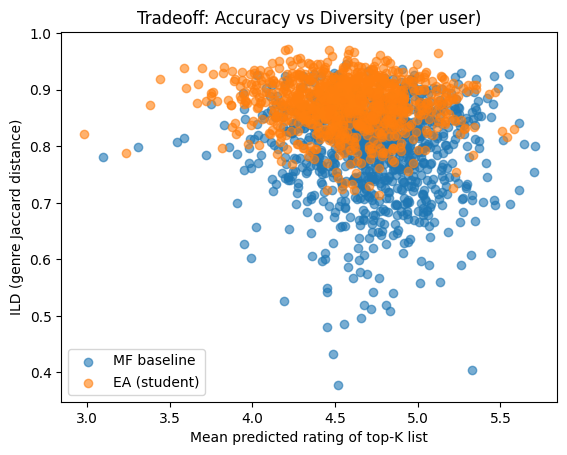

<Figure size 640x480 with 0 Axes>

In [ ]:
K = 10

mf_lists = build_user_lists(mf_recs_df, K)
ea_lists = build_user_lists(ea_recs_df, K)

mf_ild = mf_lists.apply(intra_list_diversity)
ea_ild = ea_lists.apply(intra_list_diversity)

mf_mean_score = mean_pred_score_for_user(mf_recs_df, K=K)
ea_mean_score = mean_pred_score_for_user(ea_recs_df, K=K)

# align users (intersection)
common_users = sorted(set(mf_lists.index) & set(ea_lists.index))
x_mf = mf_mean_score.reindex(common_users).to_numpy()
y_mf = mf_ild.reindex(common_users).to_numpy()
x_ea = ea_mean_score.reindex(common_users).to_numpy()
y_ea = ea_ild.reindex(common_users).to_numpy()

plt.figure()
plt.scatter(x_mf, y_mf, alpha=0.6, label="MF baseline")
plt.scatter(x_ea, y_ea, alpha=0.6, label="EA (student)")
plt.xlabel("Mean predicted rating of top-K list")
plt.ylabel("ILD (genre Jaccard distance)")
plt.title("Tradeoff: Accuracy vs Diversity (per user)")
plt.legend()
plt.show()
plt.savefig("trade_of.png")


### 12.2 Catalog Coverage at Different Recommendation Depths

Catalog coverage measures the proportion of recommendable training-catalog items that appear in recommendation lists.

Coverage is evaluated for different values of `K`.

A higher coverage value indicates that recommendations are distributed across a larger portion of the available movie catalog rather than repeatedly focusing on a small set of popular items.

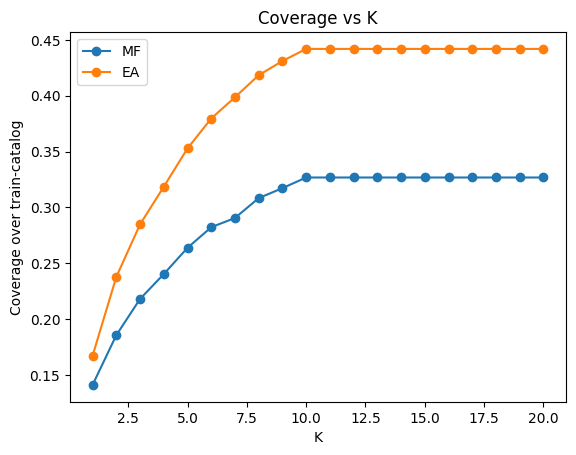

<Figure size 640x480 with 0 Axes>

In [ ]:
max_k = 20
mf_cov = coverage_curve(mf_recs_df, catalog_items=all_train_items, max_k=max_k)
ea_cov = coverage_curve(ea_recs_df, catalog_items=all_train_items, max_k=max_k)

plt.figure()
plt.plot(range(1, max_k+1), mf_cov, marker="o", label="MF")
plt.plot(range(1, max_k+1), ea_cov, marker="o", label="EA")
plt.xlabel("K")
plt.ylabel("Coverage over train-catalog")
plt.title("Coverage vs K")
plt.legend()
plt.show()
plt.savefig("converge.png")


### 12.3 Recommendation Exposure and Inequality

Item exposure measures how frequently individual movies appear across user recommendation lists.

Two visualizations are used.

#### Log-Log Exposure Distribution

Movies are ranked according to how frequently they are recommended.

The log-log plot shows whether recommendation exposure is concentrated on a small number of highly recommended movies.

#### Lorenz Curve

The Lorenz curve visualizes inequality in recommendation exposure.

A curve closer to the equality line represents a more balanced distribution of recommendations across items, while a larger deviation indicates stronger exposure concentration.

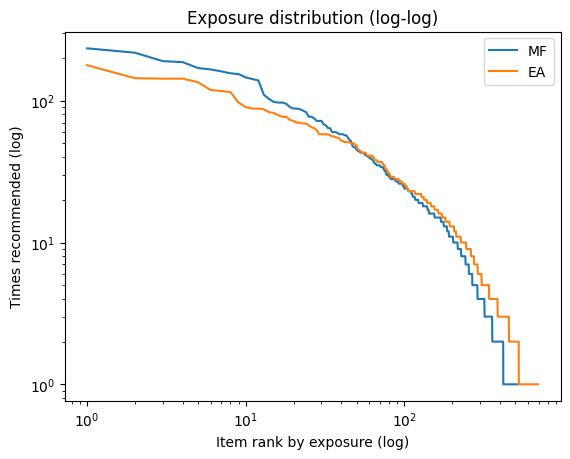

<Figure size 640x480 with 0 Axes>

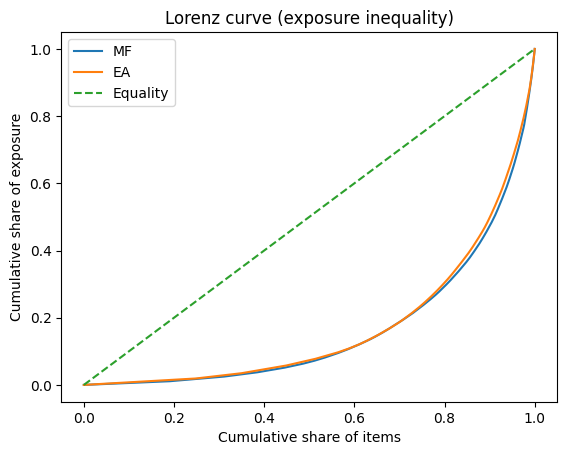

<Figure size 640x480 with 0 Axes>

In [ ]:
mf_exp = exposure_counts(mf_recs_df, K=K)
ea_exp = exposure_counts(ea_recs_df, K=K)

# Log-log exposure (popular items get recommended a lot?)
mf_vals = mf_exp.sort_values(ascending=False).to_numpy()
ea_vals = ea_exp.sort_values(ascending=False).to_numpy()

plt.figure()
plt.plot(range(1, len(mf_vals)+1), mf_vals, label="MF")
plt.plot(range(1, len(ea_vals)+1), ea_vals, label="EA")
plt.xscale("log")
plt.yscale("log")
plt.xlabel("Item rank by exposure (log)")
plt.ylabel("Times recommended (log)")
plt.title("Exposure distribution (log-log)")
plt.legend()
plt.show()
plt.savefig("exposure.png")

# Lorenz curve
mf_l = lorenz_curve_from_counts(mf_exp.values)
ea_l = lorenz_curve_from_counts(ea_exp.values)

plt.figure()
plt.plot(np.linspace(0,1,len(mf_l)), mf_l, label="MF")
plt.plot(np.linspace(0,1,len(ea_l)), ea_l, label="EA")
plt.plot([0,1],[0,1], linestyle="--", label="Equality")
plt.xlabel("Cumulative share of items")
plt.ylabel("Cumulative share of exposure")
plt.title("Lorenz curve (exposure inequality)")
plt.legend()
plt.show()
plt.savefig("curve.png")


### 12.4 Genre Exposure in Recommendation Lists

This analysis counts how frequently each movie genre appears across all Top-K recommendation positions.

The genre exposure distributions of Matrix Factorization and MOWOA are compared to determine whether multi-objective optimization changes the range of genres presented to users.

This visualization complements ILD by showing which genres contribute to recommendation diversity at the catalog level.

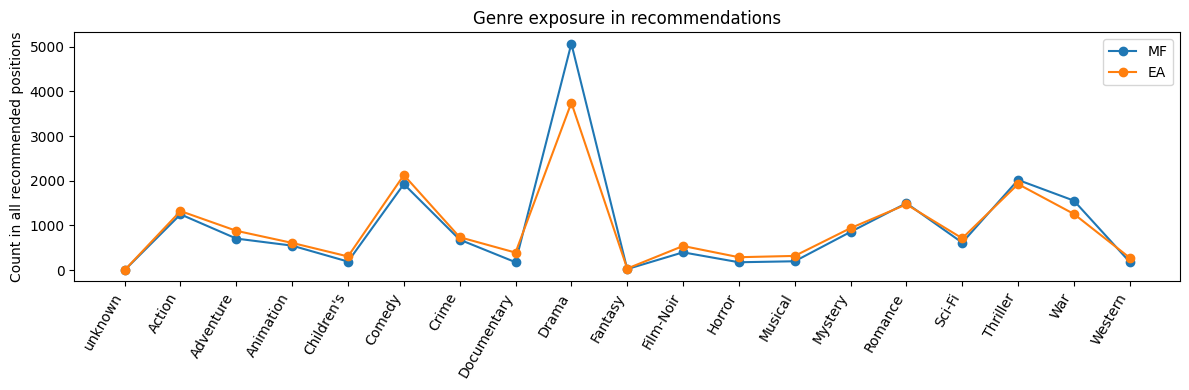

<Figure size 640x480 with 0 Axes>

In [ ]:
def genre_hist(recs_df, K, item_genres):
    tmp = recs_df.sort_values(["user_id","rank"]).groupby("user_id").head(K)
    counts = Counter()
    for iid in tmp["item_id"].astype(int).tolist():
        v = item_genres.get(iid)
        if v is None:
            continue
        for gid in np.where(v == 1)[0]:
            counts[int(gid)] += 1
    return counts

mf_g = genre_hist(mf_recs_df, K, item_genres)
ea_g = genre_hist(ea_recs_df, K, item_genres)

# Align to 0..18
x = np.arange(19)
mf_y = np.array([mf_g.get(i,0) for i in x])
ea_y = np.array([ea_g.get(i,0) for i in x])

# Genre names
genre_name = dict(zip(genres_clean["genre_id"].astype(int), genres_clean["genre"].astype(str)))
labels = [genre_name.get(i, str(i)) for i in x]

plt.figure(figsize=(12,4))
plt.plot(x, mf_y, marker="o", label="MF")
plt.plot(x, ea_y, marker="o", label="EA")
plt.xticks(x, labels, rotation=60, ha="right")
plt.ylabel("Count in all recommended positions")
plt.title("Genre exposure in recommendations")
plt.legend()
plt.tight_layout()
plt.show()
plt.savefig("genre_exposure.png")


### 12.5 Qualitative Comparison for an Example User

A qualitative example is used to inspect how the two recommendation approaches differ for an individual user.

For the selected user, the notebook displays:

- Recommendation rank
- Movie ID
- Movie title
- Associated genres

The Matrix Factorization and MOWOA recommendation lists can then be compared directly to observe differences in both relevance-oriented ranking and genre diversity.

In [ ]:
def show_user_lists(uid, K=10):
    mf_list = mf_lists.get(uid, [])
    ea_list = ea_lists.get(uid, [])

    def to_table(lst, name):
        rows = []
        for rank, iid in enumerate(lst[:K], start=1):
            title = items_raw.loc[items_raw["movie_id"]==int(iid), "title"]
            title = title.iloc[0] if len(title) else "UNKNOWN"
            # gnames = genre_names_for_item(iid, genres_clean, item_genres)
            gnames = genres_of_item(iid)
            rows.append({"model": name, "rank": rank, "item_id": int(iid), "title": title, "genres": ", ".join(gnames)})
        return pd.DataFrame(rows)

    out = pd.concat([to_table(mf_list, "MF"), to_table(ea_list, "EA")], ignore_index=True)
    display(out)

# pick any user that exists
example_user = common_users[0]
print("Example user:", example_user)
show_user_lists(example_user, K=K)


Example user: 1


,model,rank,item_id,title,genres
0,MF,1,511,Lawrence of Arabia (1962),"Adventure, War"
1,MF,2,302,L.A. Confidential (1997),"Crime, Film-Noir, Mystery, Thriller"
2,MF,3,357,One Flew Over the Cuckoo's Nest (1975),Drama
3,MF,4,709,Strictly Ballroom (1992),"Comedy, Romance"
4,MF,5,318,Schindler's List (1993),"Drama, War"
5,MF,6,657,"Manchurian Candidate, The (1962)","Film-Noir, Thriller"
6,MF,7,647,Ran (1985),"Drama, War"
7,MF,8,408,"Close Shave, A (1995)","Animation, Comedy, Thriller"
8,MF,9,963,Some Folks Call It a Sling Blade (1993),"Drama, Thriller"
9,MF,10,474,Dr. Strangelove or: How I Learned to Stop Worr...,"Sci-Fi, War"


## 13. Conclusion

This notebook developed and compared two recommendation strategies on the MovieLens 100K dataset:

1. A Matrix Factorization baseline optimized primarily for predicted rating
2. A Multi-Objective Whale Optimization recommender designed to balance predicted relevance and recommendation diversity

Matrix Factorization was first used to estimate user-item preferences and construct a candidate set of high-scoring unseen movies.

The multi-objective optimization stage then re-ranked these candidates according to two objectives:

- Mean predicted rating
- Intra-list genre diversity

A distinct-genre constraint was also incorporated into the optimization process.

The two approaches were evaluated using accuracy metrics such as Precision@K, Recall@K, NDCG@K, and MRR@K, together with beyond-accuracy measures including ILD, catalog coverage, exposure inequality, entropy, and genre diversity.

The resulting analysis provides a framework for studying the trade-off between recommendation relevance and diversity in multi-objective recommender systems.